In [3]:
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from hmmlearn import hmm

In [4]:
states = ["Sunny", "Rainy"]

transition_matrix = np.array([
    [0.8, 0.2],
    [0.4, 0.6]
]) 
print(f"Transition Matrix: ")
print(transition_matrix)

Transition Matrix: 
[[0.8 0.2]
 [0.4 0.6]]


In [5]:
def simulate_markov_chain(start_state, n_steps: int = 20): 
    current_state = states.index(start_state) 
    sequence = [start_state]
    for _ in range(n_steps): 
        current_state = np.random.choice([0, 1], p=transition_matrix[current_state])
        sequence.append(states[current_state]) 
    return sequence 
mc_sequence = simulate_markov_chain("Sunny", 15) 
print("Generated Markov Chain Sequence: ")
print(mc_sequence)

Generated Markov Chain Sequence: 
['Sunny', 'Sunny', 'Sunny', 'Sunny', 'Sunny', 'Sunny', 'Sunny', 'Rainy', 'Rainy', 'Rainy', 'Sunny', 'Sunny', 'Rainy', 'Sunny', 'Rainy', 'Sunny']


In [6]:
hidden_states = ["Hot", "Cold"] 
observations = ["IceCream", "Coffee"] 
model = hmm.MultinomialHMM(n_components=2, n_iter=50) 
model.transmat_ = np.array([
    [0.7, 0.3],
    [0.4, 0.6]
]) 
model.emissionprob_ = np.array([
    [0.8, 0.2],
    [0.3, 0.7]
]) 
model.startprob_ = np.array([0.6, 0.4]) 

print("Transition Matrix (Hidden States):")
print(model.transmat_) 
print("Emission Matrix: ") 
print(model.emissionprob_)

MultinomialHMM has undergone major changes. The previous version was implementing a CategoricalHMM (a special case of MultinomialHMM). This new implementation follows the standard definition for a Multinomial distribution (e.g. as in https://en.wikipedia.org/wiki/Multinomial_distribution). See these issues for details:
https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340


Transition Matrix (Hidden States):
[[0.7 0.3]
 [0.4 0.6]]
Emission Matrix: 
[[0.8 0.2]
 [0.3 0.7]]


In [7]:
model.n_trials = 1
obs_seq, hidden_seq = model.sample(15) 

obs_seq = obs_seq.flatten() 
hidden_seq = hidden_seq.flatten() 

decoded_obs = [observations[i] for i in obs_seq] 
decoded_hidden = [hidden_states[i] for i in hidden_seq] 

print("Generated Observations from HMM: ") 
print(decoded_obs) 
print("Actual Hidden States from HMM: ") 
print(decoded_hidden)

Generated Observations from HMM: 
['Coffee', 'IceCream', 'Coffee', 'IceCream', 'Coffee', 'IceCream', 'Coffee', 'IceCream', 'IceCream', 'Coffee', 'IceCream', 'Coffee', 'Coffee', 'IceCream', 'Coffee', 'IceCream', 'Coffee', 'IceCream', 'Coffee', 'IceCream', 'Coffee', 'IceCream', 'Coffee', 'IceCream', 'Coffee', 'IceCream', 'IceCream', 'Coffee', 'IceCream', 'Coffee']
Actual Hidden States from HMM: 
['Hot', 'Hot', 'Hot', 'Hot', 'Cold', 'Cold', 'Hot', 'Hot', 'Hot', 'Hot', 'Hot', 'Hot', 'Hot', 'Hot', 'Hot']


In [11]:
n_observations = len(observations)
X_decoded = np.zeros((len(obs_seq), n_observations)) 
X_decoded[np.arange(len(obs_seq)), obs_seq] = 1 

logprob, predicted_states = model.decode(X_decoded, algorithm="viterbi")
decoded_predicted = [hidden_states[i] for i in predicted_states] 

print("Predicted Hidden States (viterbi): ")
print(decoded_predicted)

Predicted Hidden States (viterbi): 
['Cold', 'Hot', 'Hot', 'Hot', 'Hot', 'Hot', 'Hot', 'Hot', 'Hot', 'Hot', 'Hot', 'Cold', 'Cold', 'Hot', 'Hot', 'Hot', 'Hot', 'Hot', 'Hot', 'Hot', 'Hot', 'Hot', 'Hot', 'Hot', 'Hot', 'Hot', 'Hot', 'Hot', 'Hot', 'Cold']


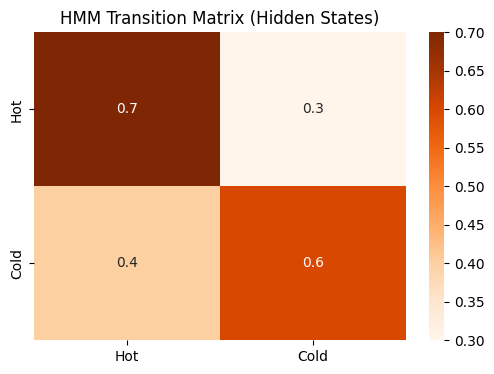

In [12]:
plt.figure(figsize=(6, 4)) 
sns.heatmap(model.transmat_, annot=True, cmap="Oranges", xticklabels=hidden_states, yticklabels=hidden_states)
plt.title("HMM Transition Matrix (Hidden States)") 
plt.show() 


Most Likely Hidden States (Viterbi): 
['Silence', 'Word1', 'Word2', 'Word2', 'Word3', 'Word3', 'Word3', 'Word3']


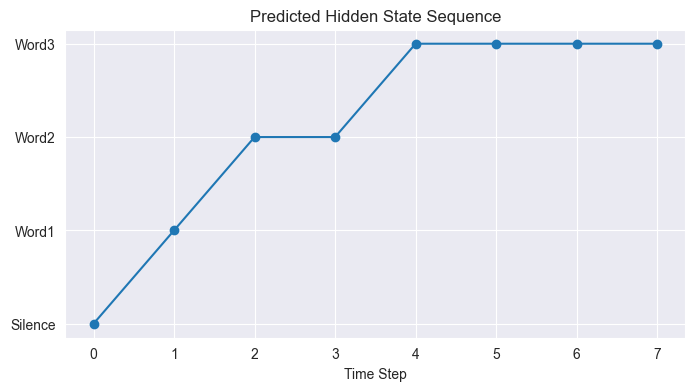

In [14]:
states = ["Silence", "Word1", "Word2", "Word3"] 
n_states = len(states)
observations = ["Loud", "Soft"]
n_observations = len(observations)

start_probability = np.array([0.8, 0.1, 0.1, 0.0]) 
transition_probability = np.array([
    [0.7, 0.2, 0.1, 0.0],
    [0.0, 0.6, 0.4, 0.0],
    [0.0, 0.0, 0.6, 0.4], 
    [0.0, 0.0, 0.0, 1.0]
])

emission_probability = np.array([
    [0.7, 0.3],
    [0.4, 0.6], 
    [0.6, 0.4],
    [0.3, 0.7]
]) 

model2 = hmm.CategoricalHMM(n_components=n_states) 
model2.startprob_ = start_probability 
model2.transmat_ = transition_probability 
model2.emissionprob_ = emission_probability 

observations_sequence = np.array([0, 1, 0, 0, 1, 1, 0, 1]).reshape(-1, 1) 
hidden_states_predicted = model2.predict(observations_sequence) 

print("Most Likely Hidden States (Viterbi): ") 
print([states[i] for i in hidden_states_predicted]) 

sns.set_style("darkgrid") 
plt.figure(figsize=(8, 4)) 
plt.plot(hidden_states_predicted, "-o") 
plt.yticks(range(n_states), states)
plt.title("Predicted Hidden State Sequence") 
plt.xlabel("Time Step")
plt.show()
